# Decision Tree Classification on Breast Cancer Data

This notebook demonstrates how to build and evaluate a Decision Tree Classifier using a breast cancer dataset.

The main aim is to understand how changing the depth of a decision tree affects model performance, overfitting, and interpretability.

## Objectives

This notebook will:
1. Load and inspect the dataset
2. Clean and prepare the data
3. Train decision trees with different depths
4. Compare model performance
5. Visualise confusion matrices, tree structure, and feature importance
6. Identify a suitable model for interpretation and use

## Dataset

The dataset contains breast cancer measurements and a diagnosis column:
- `M` = malignant
- `B` = benign

The `id` column is an identifier and will not be used for prediction.

In [1]:
# 1. Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

In [2]:
# 2. Load dataset

file_path = "breast_cancer_data.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# 3. Basic inspection

print("Columns:\n")
print(df.columns.tolist())

print("\nData types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

print("\nDiagnosis distribution:\n")
print(df["diagnosis"].value_counts())

Columns:

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data types:

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dim

In [4]:
# 4. Summary statistics

df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [5]:
# 5. Prepare features and target

df = df.copy()

# Encode diagnosis
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Drop id column
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (569, 31)
Target shape: (569,)


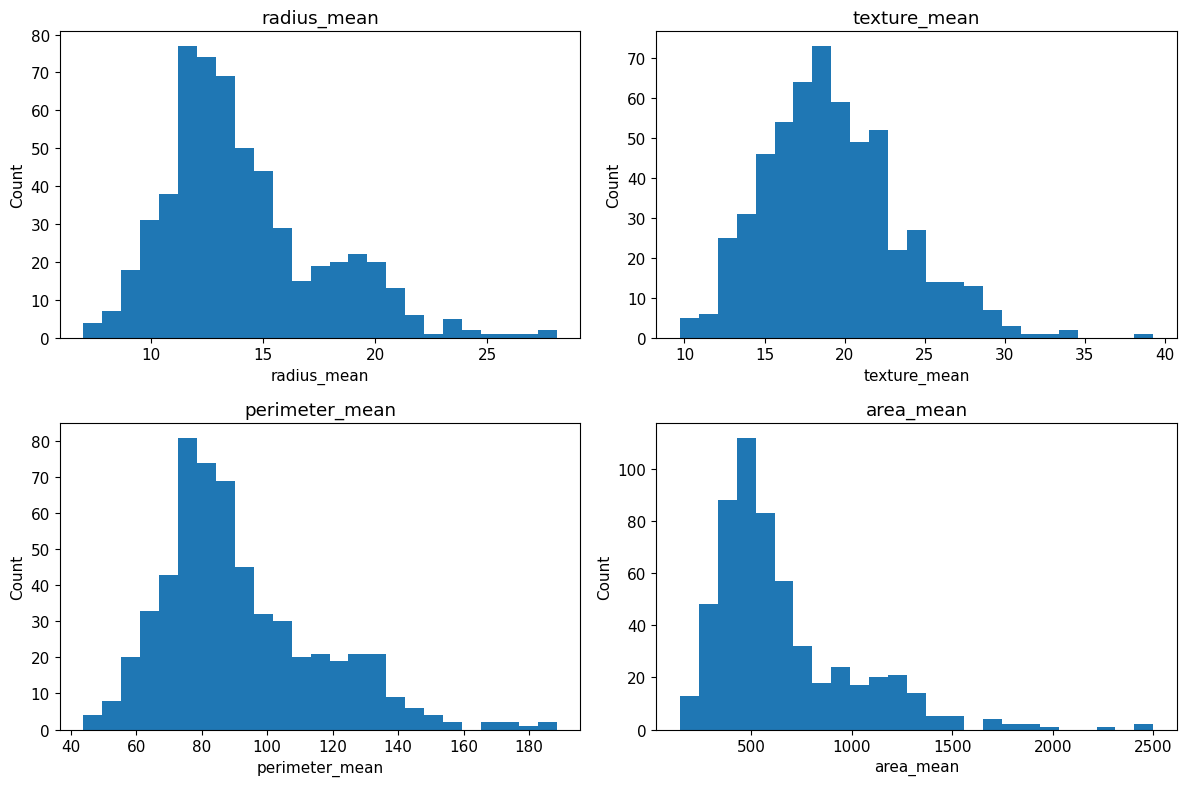

In [6]:
# 6. Plot a few feature distributions

selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), selected_features):
    ax.hist(X[feature], bins=25)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

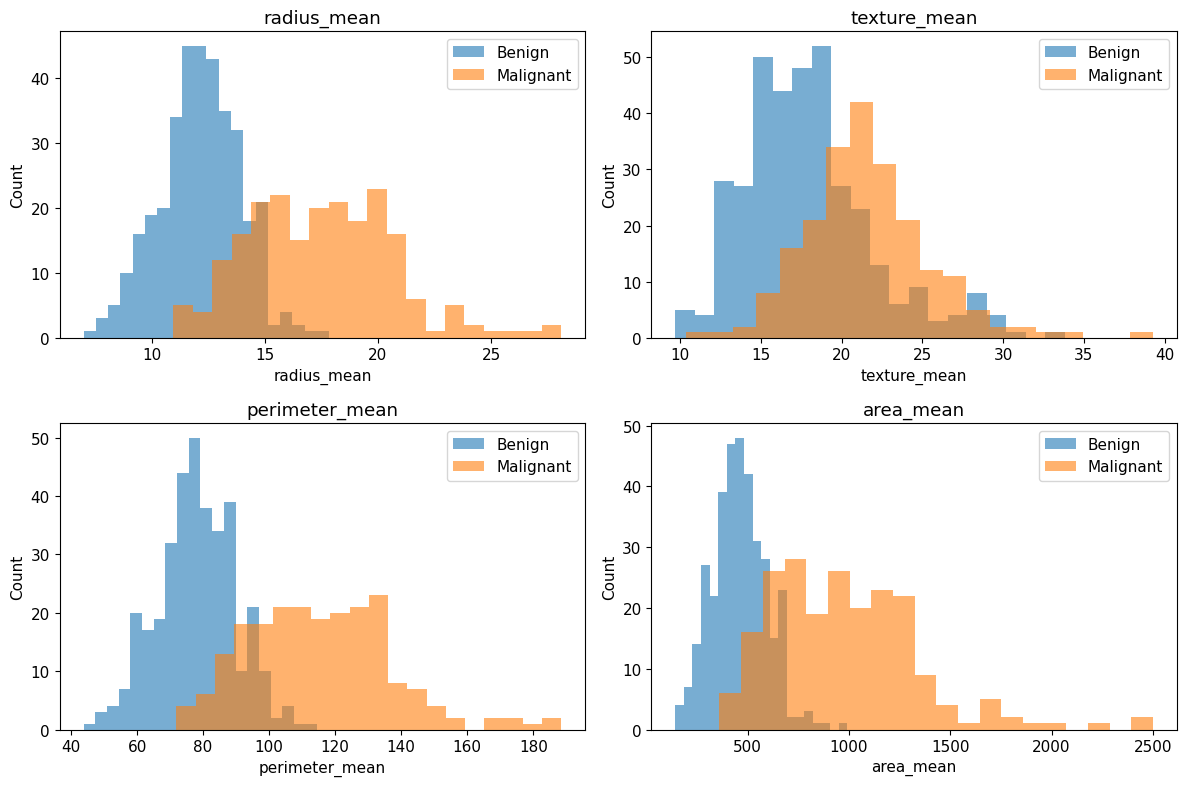

In [7]:
# 7. Compare feature distributions by diagnosis

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), selected_features):
    ax.hist(df[df["diagnosis"] == 0][feature], bins=20, alpha=0.6, label="Benign")
    ax.hist(df[df["diagnosis"] == 1][feature], bins=20, alpha=0.6, label="Malignant")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# 8. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (426, 31)
Test set shape: (143, 31)


In [9]:
# 9. Helper functions

def train_and_evaluate_tree(max_depth, X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    result = {
        "max_depth": max_depth if max_depth is not None else "None",
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    return result


def plot_conf_matrix(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(title)
    plt.show()


def get_feature_importance_df(model, feature_names):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False)
    return importance_df


def plot_feature_importance(importance_df, top_n=10, title="Top Feature Importances"):
    top_features = importance_df.head(top_n).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

In [10]:
# 10. Train trees with different max_depth values

depth_values = [1, 2, 3, 4, 5, 6, None]

results = []

for depth in depth_values:
    result = train_and_evaluate_tree(depth, X_train, X_test, y_train, y_test)
    results.append(result)

results_df = pd.DataFrame([
    {
        "max_depth": r["max_depth"],
        "train_accuracy": r["train_accuracy"],
        "test_accuracy": r["accuracy"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1_score": r["f1_score"],
        "roc_auc": r["roc_auc"]
    }
    for r in results
])

results_df

,max_depth,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc
0,1,0.929577,0.888112,0.951220,0.735849,0.829787,0.856813
1,2,0.955399,0.895105,0.975000,0.735849,0.838710,0.879769
2,3,0.967136,0.902098,0.953488,0.773585,0.854167,0.881656
3,4,0.978873,0.909091,0.976190,0.773585,0.863158,0.971593
4,5,0.988263,0.951049,0.979167,0.886792,0.930693,0.972642
5,6,0.995305,0.958042,0.979592,0.905660,0.941176,0.922222
6,None,1.000000,0.944056,0.941176,0.905660,0.923077,0.936164


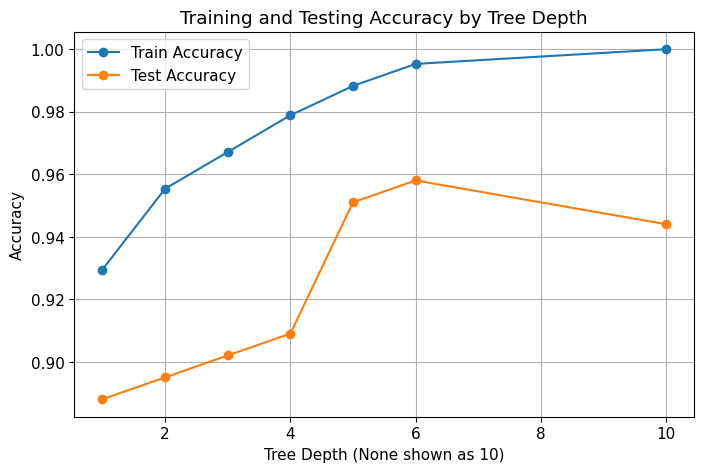

In [11]:
# 11. Plot train vs test accuracy

plot_df = results_df.copy()
plot_df["depth_numeric"] = [10 if x == "None" else x for x in plot_df["max_depth"]]

plt.plot(plot_df["depth_numeric"], plot_df["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(plot_df["depth_numeric"], plot_df["test_accuracy"], marker="o", label="Test Accuracy")
plt.xlabel("Tree Depth (None shown as 10)")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

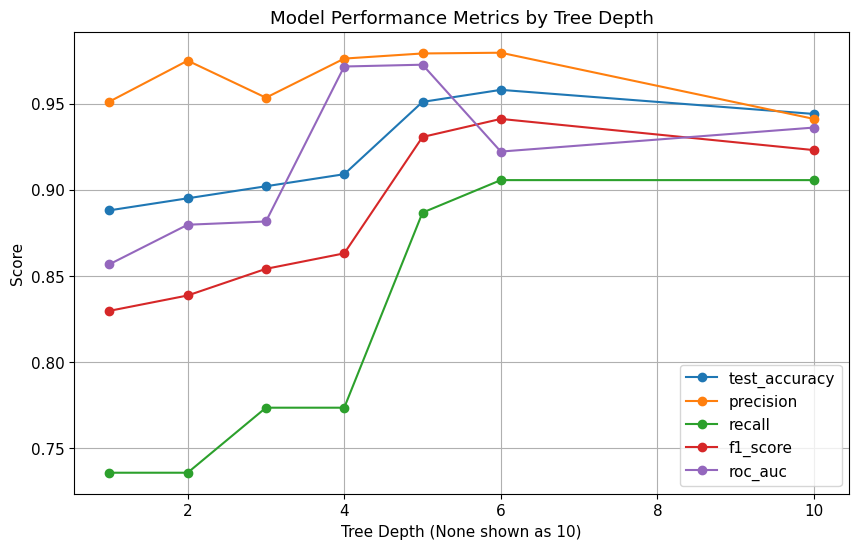

In [12]:
# 12. Plot test metrics by depth

metric_names = ["test_accuracy", "precision", "recall", "f1_score", "roc_auc"]

plt.figure(figsize=(10, 6))

for metric in metric_names:
    plt.plot(plot_df["depth_numeric"], plot_df[metric], marker="o", label=metric)

plt.xlabel("Tree Depth (None shown as 10)")
plt.ylabel("Score")
plt.title("Model Performance Metrics by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix for max_depth=1


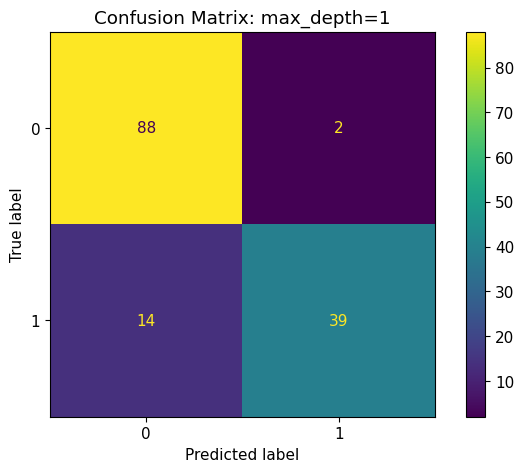

Confusion Matrix for max_depth=3


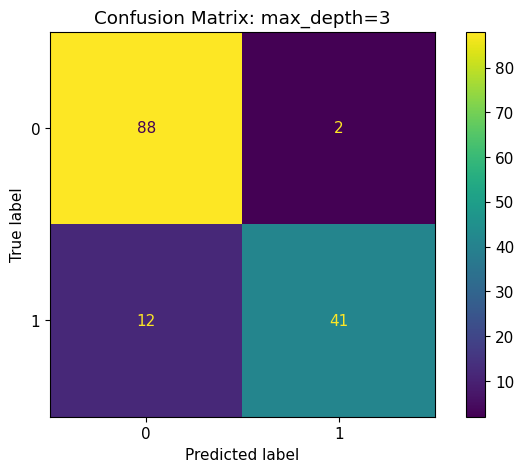

Confusion Matrix for max_depth=5


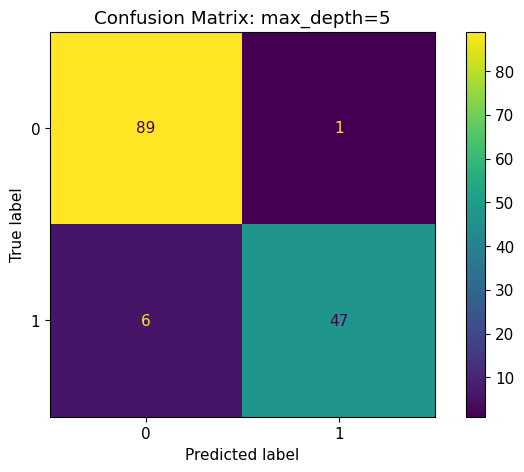

Confusion Matrix for max_depth=None


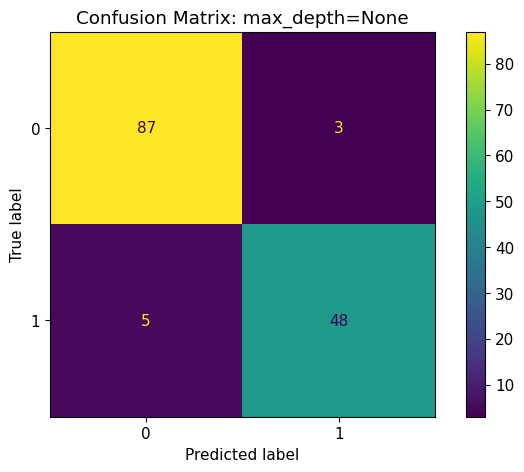

In [13]:
# 13. Confusion matrices for selected depths

selected_depths = [1, 3, 5, None]

for depth in selected_depths:
    matching_result = next(r for r in results if r["max_depth"] == (depth if depth is not None else "None"))
    print(f"Confusion Matrix for max_depth={depth}")
    plot_conf_matrix(y_test, matching_result["y_pred"], f"Confusion Matrix: max_depth={depth}")

In [14]:
# 14. Print classification reports

for depth in selected_depths:
    matching_result = next(r for r in results if r["max_depth"] == (depth if depth is not None else "None"))
    print("=" * 70)
    print(f"Classification Report for max_depth={depth}\n")
    print(classification_report(y_test, matching_result["y_pred"], target_names=["Benign", "Malignant"]))

Classification Report for max_depth=1

              precision    recall  f1-score   support

      Benign       0.86      0.98      0.92        90
   Malignant       0.95      0.74      0.83        53

    accuracy                           0.89       143
   macro avg       0.91      0.86      0.87       143
weighted avg       0.90      0.89      0.88       143

Classification Report for max_depth=3

              precision    recall  f1-score   support

      Benign       0.88      0.98      0.93        90
   Malignant       0.95      0.77      0.85        53

    accuracy                           0.90       143
   macro avg       0.92      0.88      0.89       143
weighted avg       0.91      0.90      0.90       143

Classification Report for max_depth=5

              precision    recall  f1-score   support

      Benign       0.94      0.99      0.96        90
   Malignant       0.98      0.89      0.93        53

    accuracy                           0.95       143
   macro av

In [15]:
# 15. Cross-validation by depth

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results.append({
        "max_depth": depth if depth is not None else "None",
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,max_depth,mean_cv_accuracy,std_cv_accuracy
0,1,0.887580,0.028343
1,2,0.905154,0.031950
2,3,0.915681,0.021082
3,4,0.920944,0.029813
4,5,0.920959,0.024712
5,6,0.922683,0.024401
6,None,0.910387,0.023080


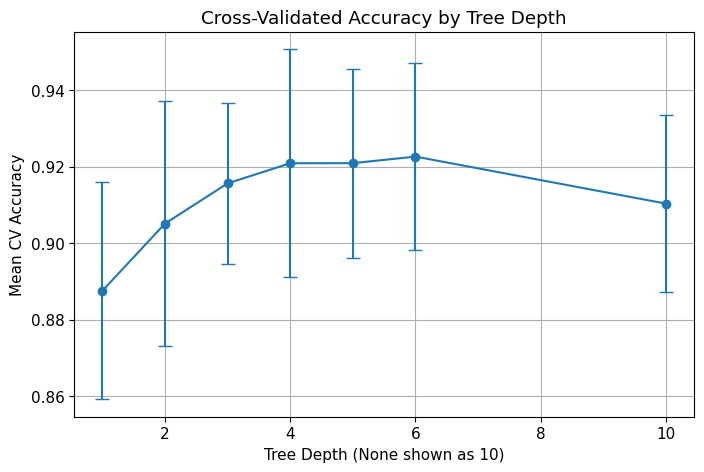

In [16]:
# 16. Plot cross-validation accuracy

cv_plot_df = cv_results_df.copy()
cv_plot_df["depth_numeric"] = [10 if x == "None" else x for x in cv_plot_df["max_depth"]]

plt.errorbar(
    cv_plot_df["depth_numeric"],
    cv_plot_df["mean_cv_accuracy"],
    yerr=cv_plot_df["std_cv_accuracy"],
    marker="o",
    capsize=5
)
plt.xlabel("Tree Depth (None shown as 10)")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross-Validated Accuracy by Tree Depth")
plt.grid(True)
plt.show()

In [17]:
# 17. Choose best model based on highest test accuracy

best_index = results_df["test_accuracy"].idxmax()
best_depth = results_df.loc[best_index, "max_depth"]

print("Best depth based on test accuracy:", best_depth)

Best depth based on test accuracy: 6


In [18]:
# 18. Refit best model

best_depth_value = None if best_depth == "None" else int(best_depth)

best_model = DecisionTreeClassifier(
    max_depth=best_depth_value,
    random_state=RANDOM_STATE
)

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Best model test accuracy:", accuracy_score(y_test, best_pred))
print("Best model precision:", precision_score(y_test, best_pred))
print("Best model recall:", recall_score(y_test, best_pred))
print("Best model F1-score:", f1_score(y_test, best_pred))
print("Best model ROC-AUC:", roc_auc_score(y_test, best_prob))

Best model test accuracy: 0.958041958041958
Best model precision: 0.9795918367346939
Best model recall: 0.9056603773584906
Best model F1-score: 0.9411764705882353
Best model ROC-AUC: 0.9222222222222222


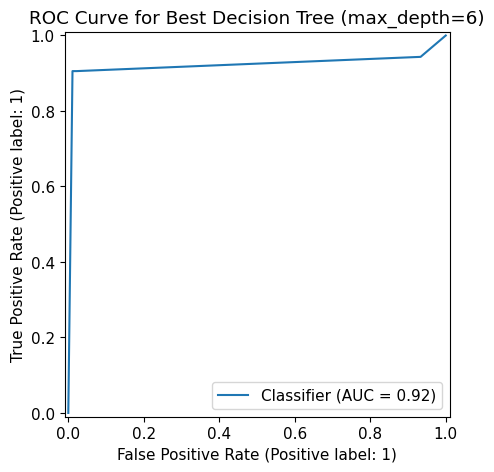

In [19]:
# 19. ROC curve

RocCurveDisplay.from_predictions(y_test, best_prob)
plt.title(f"ROC Curve for Best Decision Tree (max_depth={best_depth})")
plt.show()

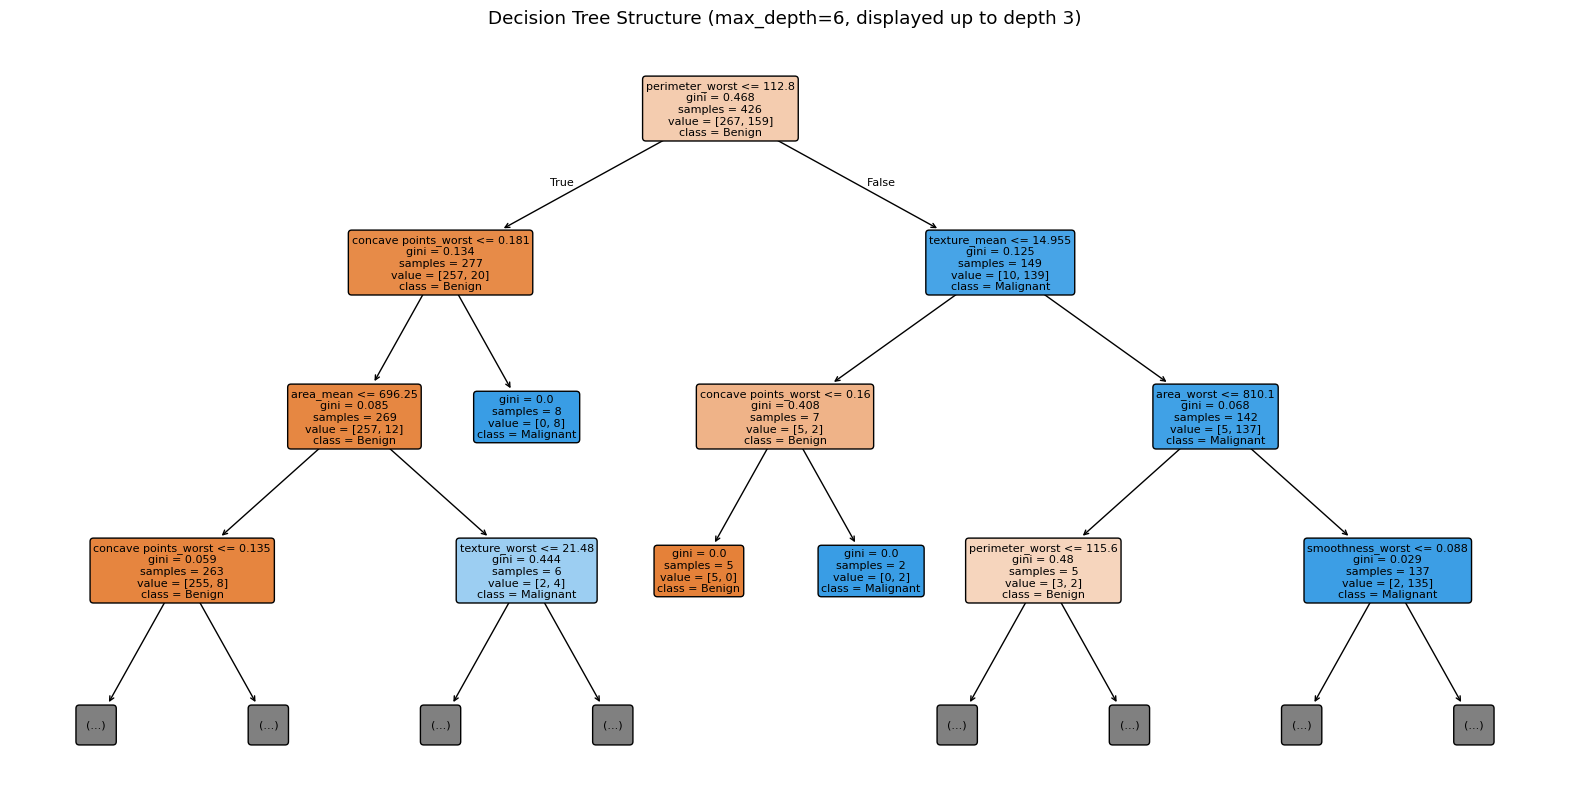

In [20]:
# 20. Plot the tree

plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title(f"Decision Tree Structure (max_depth={best_depth}, displayed up to depth 3)")
plt.show()

In [21]:
# 21. Feature importance

importance_df = get_feature_importance_df(best_model, X.columns)
importance_df.head(15)

,feature,importance
22,perimeter_worst,0.746100
27,concave points_worst,0.107999
1,texture_mean,0.059582
3,area_mean,0.024281
23,area_worst,0.016903
21,texture_worst,0.013633
24,smoothness_worst,0.010001
17,concave points_se,0.006816
8,symmetry_mean,0.006816
26,concavity_worst,0.003333


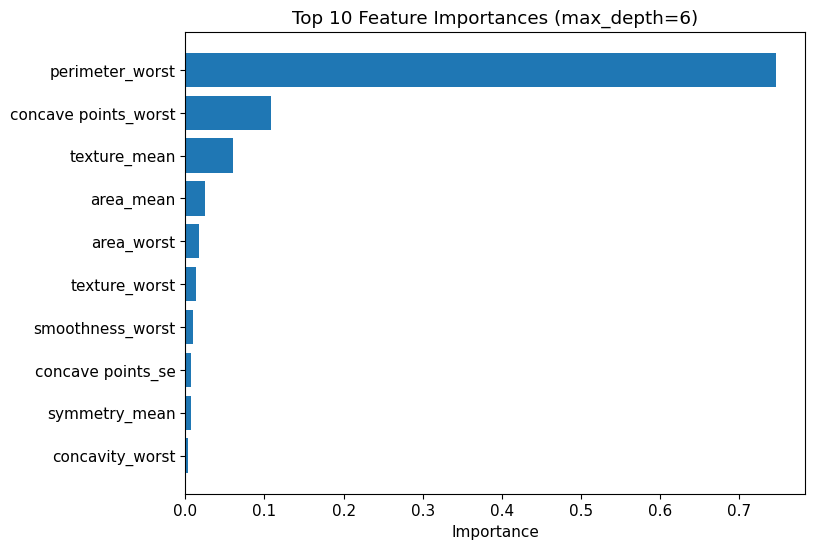

In [22]:
# 22. Plot top features

plot_feature_importance(
    importance_df,
    top_n=10,
    title=f"Top 10 Feature Importances (max_depth={best_depth})"
)

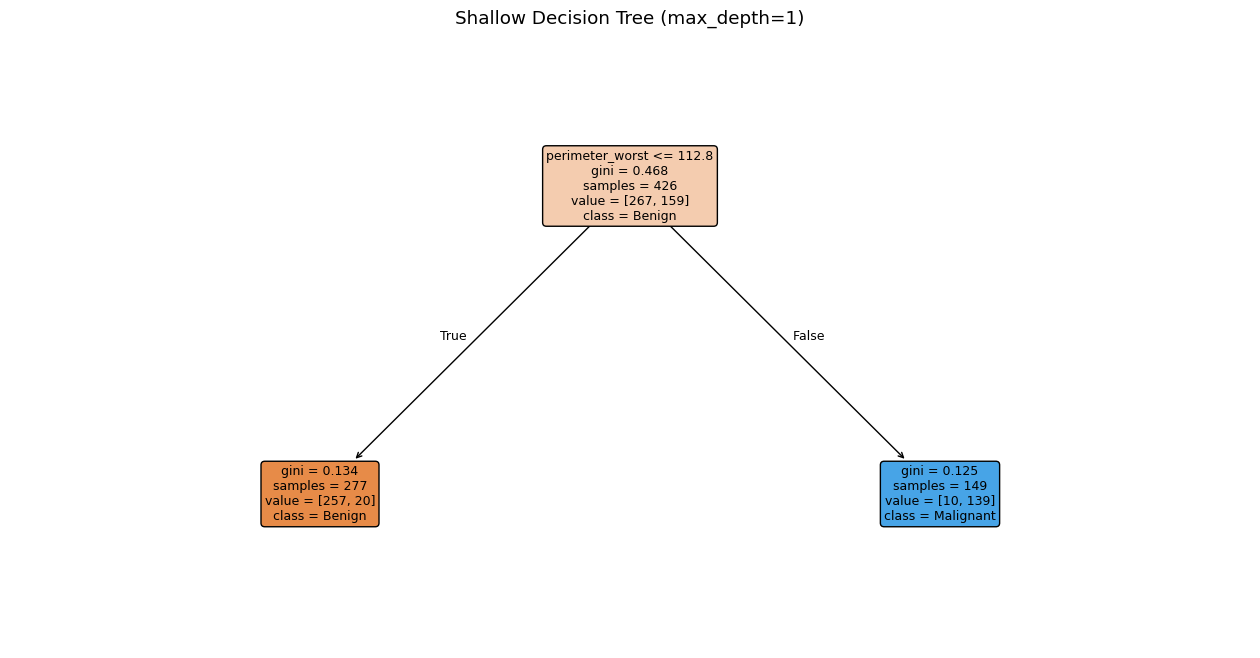

In [23]:
# 23. Plot shallow tree (depth=1)

shallow_model = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
shallow_model.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(
    shallow_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Shallow Decision Tree (max_depth=1)")
plt.show()

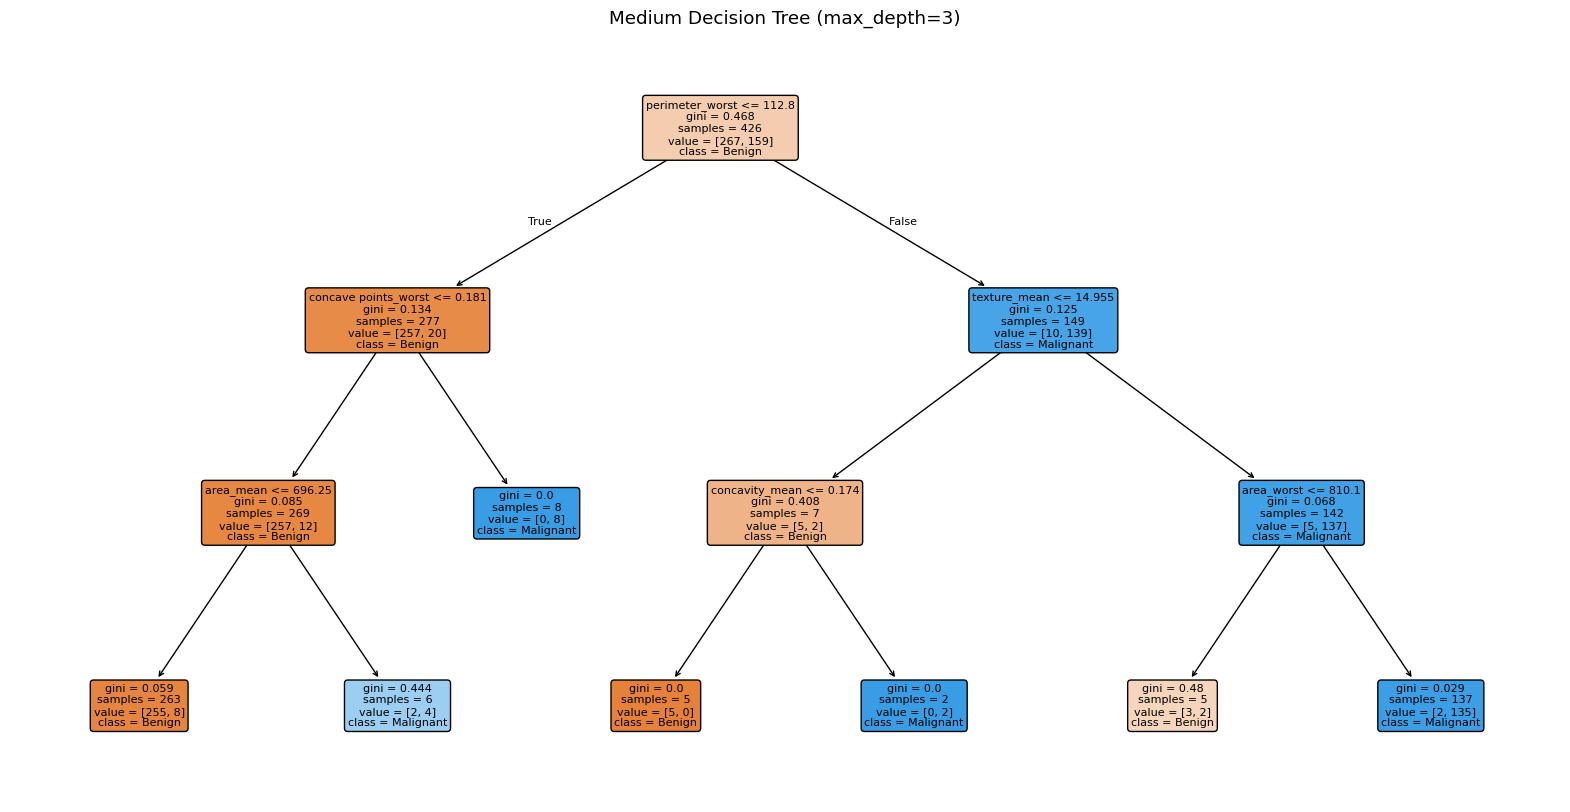

In [24]:
# 24. Plot medium-depth tree (depth=3)

medium_model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
medium_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    medium_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Medium Decision Tree (max_depth=3)")
plt.show()